## Домашнее задание 2. Введение в обучение с учителем.
### Определение возраста краба по его размерам.

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

Загрузим данные о крабах:

In [81]:
data = pd.read_csv('crabs.csv')
data.head()

,Length,Height,Weight,Age
0,1.5250,0.4000,30.419013,8.0
1,1.7000,0.4750,40.780756,10.0
2,1.1750,0.3375,13.054945,8.0
3,1.5625,0.4625,36.712603,17.0
4,1.4500,0.4000,30.702509,13.0


Наша задача - предсказать возраст по размерам краба. Выделим наш таргет в отдельную переменную:

In [82]:
target = data['Age']
data = data.drop('Age', axis=1)

и отобразим на столбчатой диаграмме:

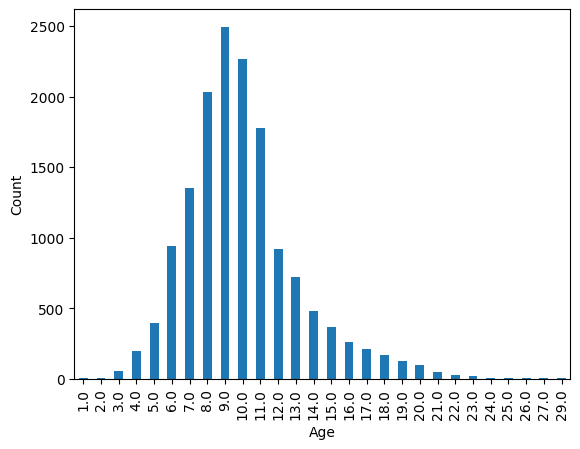

In [83]:
target.value_counts().sort_index().plot(kind='bar')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Разделим данные на тренировочную и валидационную части:

In [84]:
train_data, val_data, train_target, val_target = train_test_split(data, target, test_size=0.2, random_state=42)

### Задание 1. Линейная регрессия по одному признаку.

Пусть мы хотим обучить линейную регрессию вида $\hat{y_i} = ax_i + b$. Напомним, что оптимальное решение достигается при

$$ b^* = \overline{y} $$
$$ a^* = \frac{\sum_{i=1}^N(y_i - \overline{y})(x_i - \overline{x})}{\sum_{i=1}^N(x_i - \overline{x})^2} $$

Вашей задачей будет реализовать эти формулы с помощью *numpy*. \
**Пользоваться готовым решением из sklearn в этом задании запрещено!**

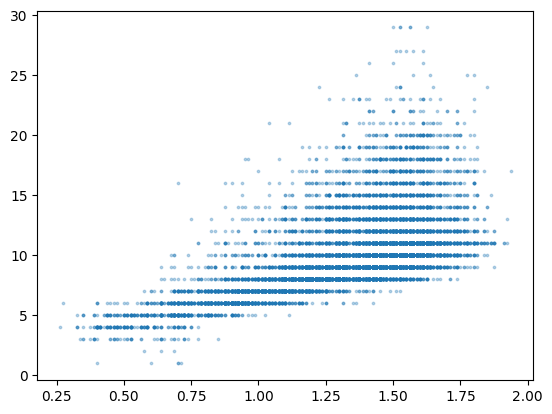

In [85]:
# Наш признак - длина краба
x = train_data["Length"].to_numpy()
# Наш таргет - возраст краба
y = train_target.to_numpy()

plt.scatter(x, y, s=3, alpha=0.3)
plt.show()

Сначала посчитайте средние значения признака и таргета.

In [ ]:
x_mean = ...
y_mean = ...

print(x_mean, y_mean)
assert np.allclose(x_mean, 1.313, atol=1e-3)
assert np.allclose(y_mean, 9.966, atol=1e-3)

1.312909375 9.966


На графике средний возраст будет выглядеть так:

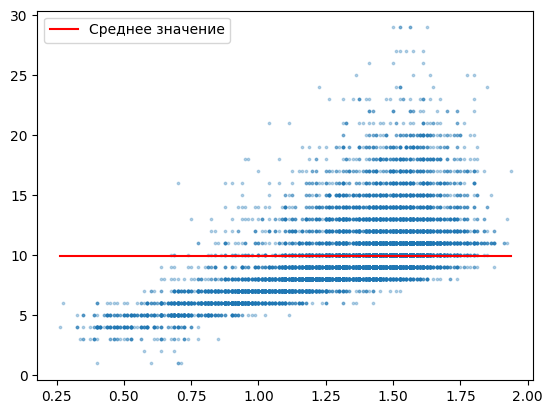

In [87]:
plt.scatter(x, y, s=3, alpha=0.3)
plt.plot([x.min(), x.max()], [y_mean, y_mean], c='red', label='Среднее значение')
plt.legend()
plt.show()

Теперь посчитайте по формуле оптимальные значения $a^*, b^*$.

In [ ]:
a_star = ...
b_star = ...

print(a_star, b_star)
assert np.allclose(a_star, 7.040, atol=1e-3)
assert np.allclose(b_star, 0.722, atol=1e-3)

7.040701545558199 0.7221969342596495


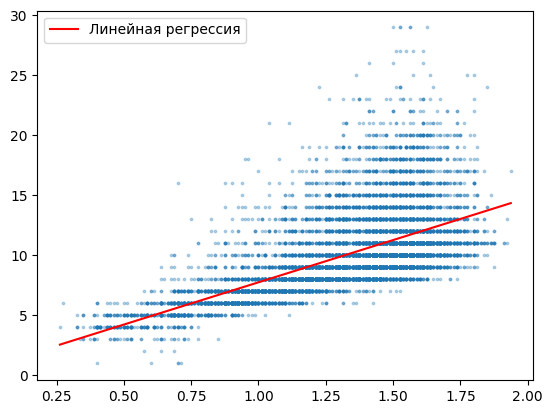

In [89]:
plt.scatter(x, y, s=3, alpha=0.3)
plt.plot([x.min(), x.max()], [b_star + a_star * x.min(), b_star + a_star * x.max()], c='red', label='Линейная регрессия')
plt.legend()
plt.show()

In [90]:
mse_loss = ((y - (a_star * x + b_star)) ** 2).mean()
print(mse_loss)
assert np.allclose(mse_loss, 6.479, atol=1e-3)

6.479032034691464


### Задание 2. Линейная регрессия на нескольких признаках.

Теперь обучите модель линейной регрессии с помощью библиотеки *sklearn*.

In [ ]:
reg = LinearRegression()
... # Обучите модель
predicted_val_target = ... # Получите предсказания на валидационной выборке

mse_loss = ... # Посчитайте среднюю квадратичную ошибку на валидационной выборке
print(mse_loss)
assert mse_loss < 10000, "Нужно усреднить ошибку"
assert mse_loss < 6.0, "Лосс слишком большой, вы точно обучаете регрессию на всех признаках?"

5.854564378700546


Наверняка можно лучше. Попробуйте добавить новых признаков и обучить модель линейной (полиномиальной) регресии получше. Добавляйте новые признаки к копии таблицы `train_feat` и `val_feat`, чтобы не оставить неизменными таблицы для других заданий. \
*Будьте осторожны, чрезмерное увеличение количества признаков ведёт к переобучению!*

In [ ]:
train_feat = train_data[["Length", "Height", "Weight"]].copy()
val_feat = val_data[["Length", "Height", "Weight"]].copy()

# Добавляйте новые признаки к train_feat
...

reg = LinearRegression()
... # Обучите модель
predicted_val_target = ... # Получите предсказания на валидационной выборке

mse_loss = ... # Посчитайте среднюю квадратичную ошибку на валидационной выборке
print(mse_loss)
assert mse_loss < 5.7, "Лосс слишком большой"

5.695155075228227


### Задание 3. Дерево решений.

Обучите дерево решений из *sklearn* с параметрами по умолчанию.

In [ ]:
reg = DecisionTreeRegressor(random_state=42)
... # Обучите модель
predicted_train_target = reg.predict(train_data) # Получите предсказания для обучающих данных
predicted_val_target = reg.predict(val_data) # Получите предсказания для валидационных данных

train_mse_loss = ... # Посчитайте среднюю квадратичную ошибку на обучающей выборке
mse_loss = ... # Посчитайте среднюю квадратичную ошибку на валидационной выборке
print(train_mse_loss, mse_loss)
assert train_mse_loss < 1.0, "Обучите дерево с параметрами по умолчанию" 

0.3586833333333334 11.789003796296296


Как мы видим, без подкрутки параметров дерево очень сильно переобучилось. Подберите глубину дерева так, чтобы получить лосс на валидации поменьше.

In [ ]:
reg = DecisionTreeRegressor(...) # Подберите max_depth
... # Обучите модель
predicted_train_target = reg.predict(train_data) # Получите предсказания для обучающих данных
predicted_val_target = reg.predict(val_data) # Получите предсказания для валидационных данных

train_mse_loss = ... # Посчитайте среднюю квадратичную ошибку на обучающей выборке
mse_loss = ... # Посчитайте среднюю квадратичную ошибку на валидационной выборке
print(train_mse_loss, mse_loss)
assert mse_loss < 5.9, "Лосс слишком большой"


5.6401995429111 5.800369206027755


### Задание 4*. Ансамблирование.

Хоть каждая из моделей и не очень, мы можем взять средний ответ моделей, чтобы нивелировать их недостатки. Попробуйте обучить несколько моделей (как линейных регрессий, так и деревьев), чтобы получить лосс на валидации меньше, чем могла бы получить каждая из моделей в отдельности.

In [ ]:
regs = [...] # Создайте список моделей в ансамбле
n = len(regs)
preds = []
for reg in regs:
    # Обучите модели и положите в preds предсказание на валидационной выборке
    ...

predicted_val_target = sum(preds) / n
mse_loss = ... # Посчитайте среднюю квадратичную ошибку на валидационной выборке
print(mse_loss)

assert mse_loss < 5.76, "Лосс слишком большой"

5.758084429137933


### Задание 5. CatBoost.

Конечно, есть готовые решения, которые реализуют методы помощнее обычных деревьев и линейных регрессий. Один их таких методов - *градиентный бустинг*.

Установите библиотеку *catboost*. Обучите регрессор и порадуйтесь) Можете поиграться с параметрами, чтобы выбить поменьше лосс.

In [96]:
%pip install catboost

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\serza\source\ai_circle\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [ ]:
from catboost import CatBoostRegressor

reg = CatBoostRegressor(n_estimators=100, random_state=42)
... # Обучите модель
predicted_val_target = ... # Получите предсказания на валидационной выборке
mse_loss = ... # Посчитайте среднюю квадратичную ошибку на валидационной выборке
print(mse_loss)
assert mse_loss < 5.7, "Лосс слишком большой, попробуйте поставить побольше n_estimators"